##Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

##Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('train.csv')
df.head()

Saving train.csv to train (5).csv


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


##Data Overview

In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


##Missing Values Handling

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


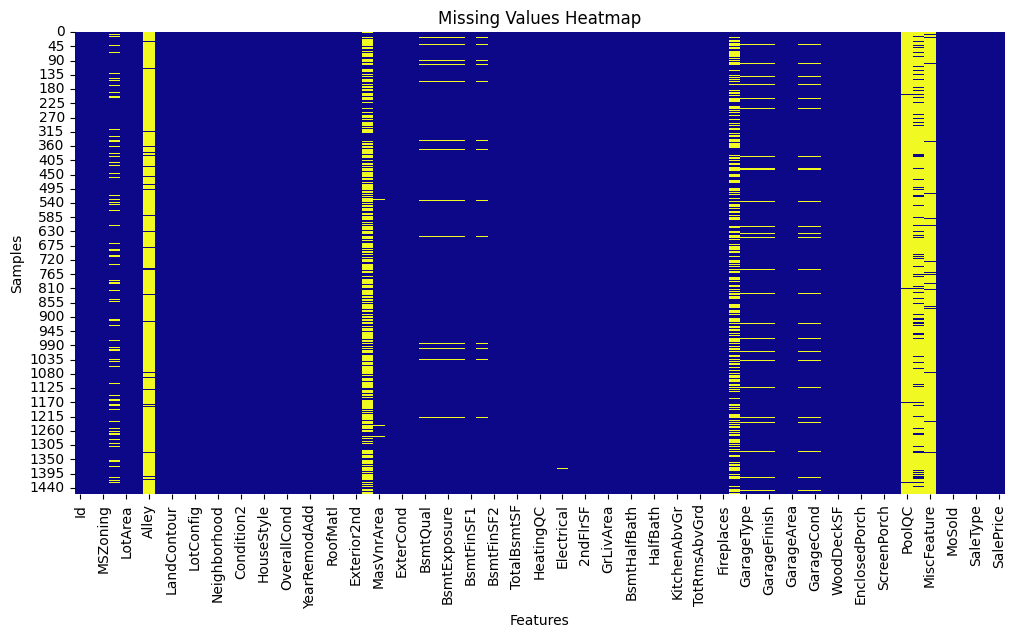

In [4]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.head(10))

# 🔽 ADD THIS HERE
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False, cmap='plasma')
plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.show()

# Drop columns with too many missing values
df = df.drop(columns=missing[missing > 100].index)

# Fill remaining missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna('None')

##Feature Selection & Encoding

In [5]:
# Convert categorical columns into numeric
df = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print(X.shape)

(1460, 239)


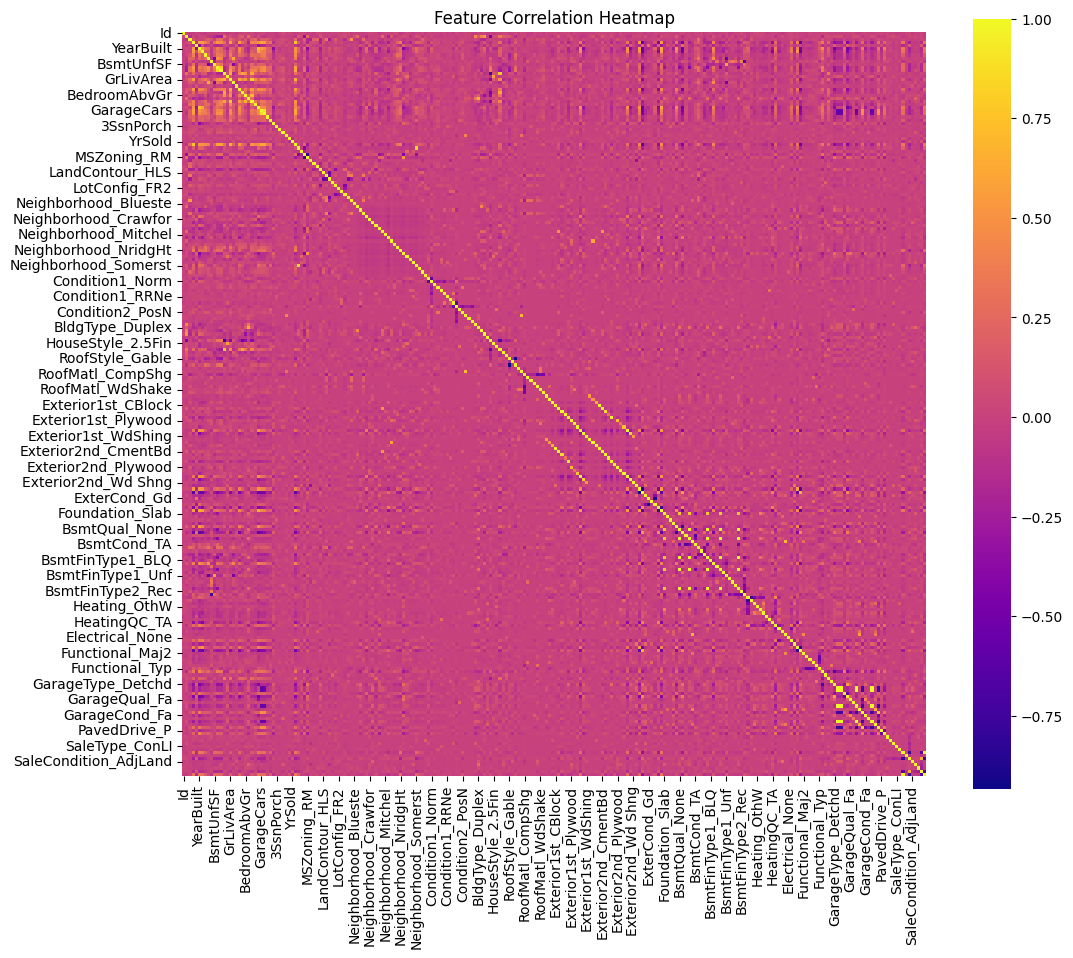

In [6]:
plt.figure(figsize=(12,10))

correlation = df.corr()

sns.heatmap(
    correlation,
    cbar=True,
    fmt='.1f',
    annot=False,
    square=True,
    cmap='plasma'
)

plt.title("Feature Correlation Heatmap")
plt.show()

##Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 239)
Test shape: (292, 239)


##Train Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##Predictions

In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

##Evaluation (RMSE & R²)

In [10]:
# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# R² Score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

print("\nModel Analysis:")
if train_rmse < test_rmse:
    print("The model may have slight overfitting (training error is lower than testing error).")
else:
    print("The model is well generalized.")

Train RMSE: 19821.92242814869
Test RMSE: 52207.25184812712
Train R2: 0.9341260306761526
Test R2: 0.6446569452313674

Model Analysis:
The model may have slight overfitting (training error is lower than testing error).


##Visualization

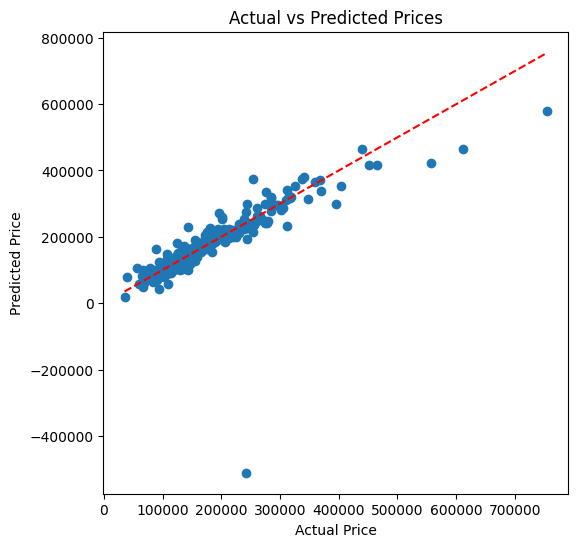

In [11]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

##Interpret Coefficients

In [12]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
coefficients.head(10)

print("\nInterpretation:")
print("Positive coefficients indicate features that increase house price, while negative coefficients indicate features that decrease house price.")


Interpretation:
Positive coefficients indicate features that increase house price, while negative coefficients indicate features that decrease house price.


##Markdown Insight
Insights:
- Features with higher positive coefficients (e.g., OverallQual, GrLivArea) significantly increase house prices.
- Features with negative coefficients reduce the predicted price.
- This shows that structural and quality-related features are strong predictors of house value.

##Save Model

In [13]:
import joblib

joblib.dump(model, 'house_price_model.pkl')
print("Model saved successfully!")

Model saved successfully!


##Example Prediction

In [14]:
# Take one sample from test set
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Price:", prediction[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 154692.074437666
Actual Price: 154500
